In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.psd import aLIGOZeroDetHighPower
from simple_pe.waveforms import make_waveform
from pycbc.filter.matchedfilter import matched_filter

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

lal.MSUN_SI != Msun


2026-03-18  11:32:14 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-03-18  11:32:14 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default
2026-03-18  11:32:25 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-03-18  11:32:25 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


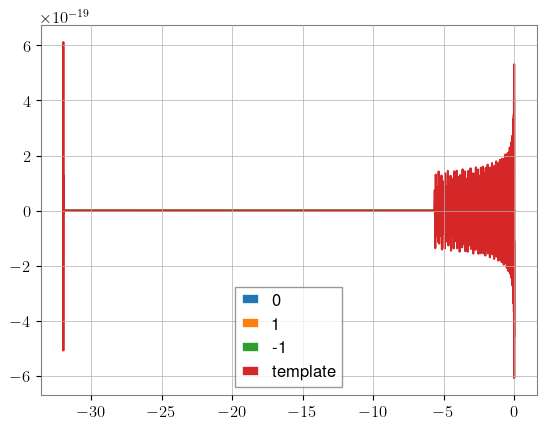

In [62]:
# Generate harmonics, template, psd
psd = aLIGOZeroDetHighPower(int(32*4096)//2 + 1, 1/32, 10)
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'chi_align': 0, 'ecc10sqrd': 0.2**2}
harms = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'TEOBResumS-Dali-Harms', n_ecc_harms=3, ecc_harm_psd=psd)
template = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'TEOBResumS-Dali')

# Make plot
for i in harms.keys():
    h_ts = harms[i].to_timeseries()
    plt.plot(h_ts.sample_times, h_ts, label=str(i))
temp_ts = template.to_timeseries()
plt.plot(temp_ts.sample_times, temp_ts, label='template')
plt.legend()
plt.show()

In [15]:
def calculate_mode_snr(strain_data, ifo_psd, waveform_modes, t_start, t_end,
                       f_low, modes, dominant_mode=0,
                       subsample_interpolation=True):

    if dominant_mode not in waveform_modes.keys():
        print("Please give the waveform for the dominant mode")
        return

    s = matched_filter(waveform_modes[dominant_mode], strain_data, ifo_psd,
                       low_frequency_cutoff=f_low)
    plt.plot(s.sample_times, np.abs(s), label='before crop')
    snr = s.crop(t_start - s.start_time, s.end_time - t_end)
    plt.plot(snr.sample_times, np.abs(snr), label='after crop')
    plt.legend()
    plt.show()

    # find the peak and use this for the other modes later
    i_max = snr.abs_arg_max()
    t_max = snr.sample_times[i_max]
    if subsample_interpolation:
        from pycbc.filter.matchedfilter import quadratic_interpolate_peak
        # protect against peak being at the start of the timeseries
        left = abs(snr[-1]) if i_max == 0 else abs(snr[i_max - 1])
        middle = abs(snr[i_max])
        # protect against peak being at the end of the timeseries
        right = abs(snr[0]) if i_max == (len(snr) - 1) else abs(snr[i_max + 1])
        print(left, middle, right)
        id_shift, maxsnr = quadratic_interpolate_peak(left, middle, right)
        t_max += id_shift * snr.delta_t
    z = {}
    for mode in modes:
        s = matched_filter(
            waveform_modes[mode], strain_data, psd=ifo_psd,
            low_frequency_cutoff=f_low,
            high_frequency_cutoff=ifo_psd.sample_frequencies[-1],
            sigmasq=None
            )
        snr_ts = s.crop(t_start - s.start_time, s.end_time - t_end)

        if subsample_interpolation:
            try:
                z[mode] = snr_ts.at_time(t_max, interpolate='quadratic')
            except Exception as e:
                warnings.warn(
                    f"PyCBC snr interpolation failed for mode {mode} with"
                    f" error: {e}. Falling back to index-based snr peak."
                )
                z[mode] = snr_ts[i_max]
        else:
            z[mode] = snr_ts[i_max]

    return z, t_max


searching for peak on whole range


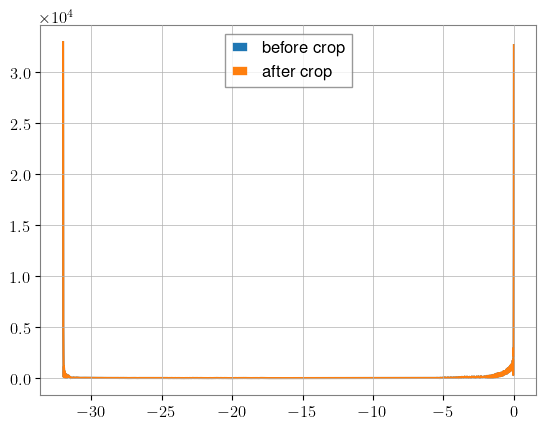

32668.47764902058 32966.235575974504 32936.21613087203
[(0, 32992.11084153291), (1, 7036.217408599544), (-1, 2435.4967841365524)] -31.999656148272738

searching for peak with crop


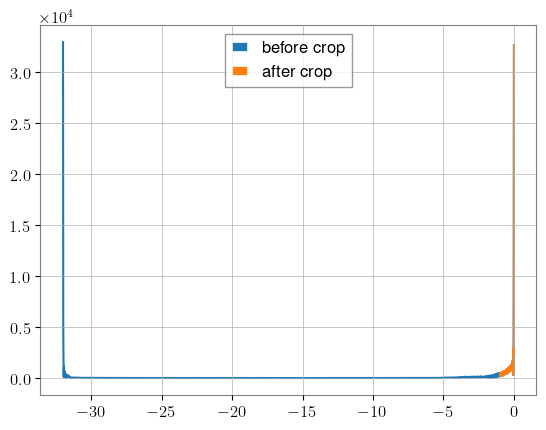

32056.338573609588 32668.47764902058 371.85743949375114
[(0, 32403.901452936963), (1, 7622.934042976398), (-1, 1089.9241806660136)] -0.00011752840366837694

searching for peak with crop, without subsample_interpolation


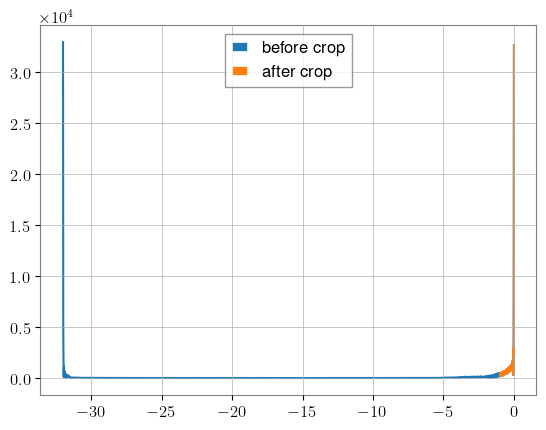

[(0, 32668.47764902058), (1, 7498.676770827605), (-1, 1296.6704475626282)] 6.250000517127319e-10


In [64]:
print('\nsearching for peak on whole range')
z, t = calculate_mode_snr(template, psd, harms, temp_ts.sample_times[0], temp_ts.sample_times[-1]+(temp_ts.sample_times[1]-temp_ts.sample_times[0]), 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop')
z, t = calculate_mode_snr(template, psd, harms, -1, 1, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop, without subsample_interpolation')
z, t = calculate_mode_snr(template, psd, harms, -1, 1, 20, [0, 1, -1], subsample_interpolation=False)
print([(i, np.abs(z[i])) for i in z.keys()], t)

The subsample interpolation breaks down when a limiting t_start/t_end is provided as it incorrectly cuts off the peak in snr at the start of the timeseries.

In [56]:
def calculate_mode_snr_fixed(strain_data, ifo_psd, waveform_modes, t_start, t_end,
                             f_low, modes, dominant_mode=0,
                             subsample_interpolation=True):

    if dominant_mode not in waveform_modes.keys():
        print("Please give the waveform for the dominant mode")
        return

    time_shift = t_start - strain_data.start_time
    # tmp_modes = {i: waveform_modes[i].copy() for i in modes}
    # tmp_modes = {i: tmp_modes[i].cyclic_time_shift(-time_shift) for i in modes}
    tmp_strain = strain_data.copy().cyclic_time_shift(-time_shift)

    s = matched_filter(waveform_modes[dominant_mode], tmp_strain, ifo_psd,
                       low_frequency_cutoff=f_low)
    plt.plot(s.sample_times, np.abs(s), label='before crop')
    snr = s.crop(t_start - s.start_time, s.end_time - t_end)
    plt.plot(snr.sample_times, np.abs(snr), label='after crop')
    plt.legend()
    plt.show()

    # find the peak and use this for the other modes later
    i_max = snr.abs_arg_max()
    t_max = snr.sample_times[i_max]
    if subsample_interpolation:
        from pycbc.filter.matchedfilter import quadratic_interpolate_peak
        # protect against peak being at the start of the timeseries
        left = abs(snr[-1]) if i_max == 0 else abs(snr[i_max - 1])
        middle = abs(snr[i_max])
        # protect against peak being at the end of the timeseries
        right = abs(snr[0]) if i_max == (len(snr) - 1) else abs(snr[i_max + 1])
        print(left, middle, right)
        id_shift, maxsnr = quadratic_interpolate_peak(left, middle, right)
        t_max += id_shift * snr.delta_t
    z = {}
    for mode in modes:
        s = matched_filter(
            waveform_modes[mode], tmp_strain, psd=ifo_psd,
            low_frequency_cutoff=f_low,
            high_frequency_cutoff=ifo_psd.sample_frequencies[-1],
            sigmasq=None
            )
        snr_ts = s.crop(t_start - s.start_time, s.end_time - t_end)

        if subsample_interpolation:
            try:
                z[mode] = snr_ts.at_time(t_max, interpolate='quadratic')
            except Exception as e:
                warnings.warn(
                    f"PyCBC snr interpolation failed for mode {mode} with"
                    f" error: {e}. Falling back to index-based snr peak."
                )
                z[mode] = snr_ts[i_max]
        else:
            z[mode] = snr_ts[i_max]

    delta_t = 1/(len(strain_data)*strain_data.delta_f)
    end_time = strain_data.start_time + 1/strain_data.delta_f - delta_t
    print(end_time)
    if t_max > end_time:
        t_max -= strain_data.duration

    return z, t_max


searching for peak on whole range


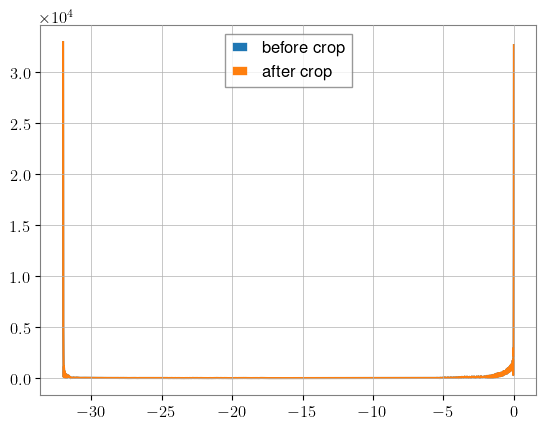

32668.47764902058 32966.235575974504 32936.21613087203
-0.000244133
[(0, 32992.11084153291), (1, 7036.217408599544), (-1, 2435.4967841365524)] -31.999656148272738

searching for peak with crop


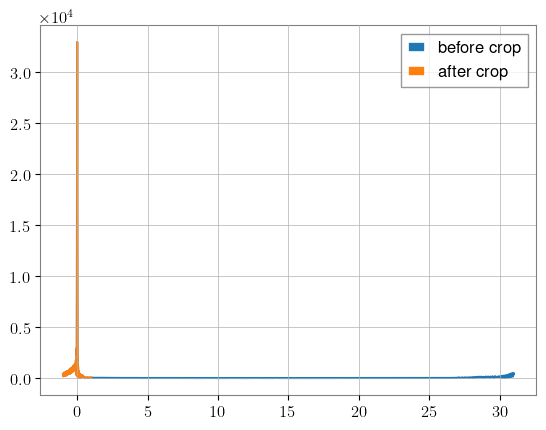

32668.473531998487 32966.23436372438 32936.21788175405
-0.000244133
[(0, 32992.11078674607), (1, 7036.217421931956), (-1, 2435.4967352988765)] -31.999656146444668

searching for peak with crop, without subsample_interpolation


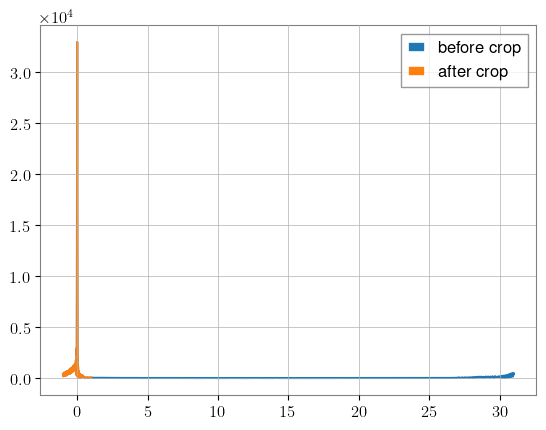

-0.000244133
[(0, 32966.23436372438), (1, 7183.368379613213), (-1, 2075.579376839556)] -31.999755859375


In [66]:
print('\nsearching for peak on whole range')
z, t = calculate_mode_snr_fixed(template, psd, harms, temp_ts.sample_times[0], temp_ts.sample_times[-1]+(temp_ts.sample_times[1]-temp_ts.sample_times[0]), 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop')
z, t = calculate_mode_snr_fixed(template, psd, harms, -1, 1, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop, without subsample_interpolation')
z, t = calculate_mode_snr_fixed(template, psd, harms, -1, 1, 20, [0, 1, -1], subsample_interpolation=False)
print([(i, np.abs(z[i])) for i in z.keys()], t)

This now recovers the correct snrs and times.